# check whether additional ALPT bias parameters are necessary

In [1]:
import numpy as np
from hodalpt import priors
from hodalpt.sims import alpt as CS
from nbodykit.lab import ArrayCatalog, FFTPower

In [2]:
import matplotlib.pyplot as plt

In [3]:
import copy

## fiducial Quijote+HOD clustering
This is based on the ~MAP of HOD constraints from the bispectrum

In [4]:
from hodalpt.sims.quijote import HODgalaxies
theta_hod = {}
theta_hod['logMmin'] = 13.0
theta_hod['sigma_logM'] = 0.4
theta_hod['logM0'] = 13.67
theta_hod['logM1'] = 13.68
theta_hod['alpha'] = 0.79
theta_hod['Abias'] = 0.0
theta_hod['eta_conc'] = 1.11
theta_hod['eta_cen'] = 0.31
theta_hod['eta_sat'] = 0.85

hod = HODgalaxies(theta_hod, '/Users/mcc3842/CosmicSim2025/data/quijote/fiducial_HR/0')

_cat = ArrayCatalog({'Position': np.array(hod['Position'])}, BoxSize=1000.) 
r_hod = FFTPower(_cat, mode='1d', Nmesh=256, dk=0.005, kmin=0.008, los=[0,0,1], poles=[0])

/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/phase_space_models/analytic_models/satellites/nfw/biased_nfw_phase_space.py:225: UserWarning: You have selected 18 bins to digitize host halo concentration 
and 96 bins to digitize the galaxy bias parameter.
To populate mocks, the BiasedNFWPhaseSpace class builds a lookup table with shape (18, 96, 101),
one entry for every numerical solution to the Jeans equation.
Using this fine of a binning requires a long pre-computation of 174528 integrals
.Make sure you actually need to use so many bins
  warn(lookup_table_performance_warning.format(*args))
/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/factories/hod_model_factory.py:890: UserWarning: The composite model received multiple component models 
with a new_haloprop_func_dict that use the conc_NFWmodel key. 
Ignoring the one that appears in the profile component for satellite

In [5]:
ng_hod = np.array(hod['Position']).shape[0]

In [6]:
print(ng_hod)

424793


In [ ]:
from hodalpt import stats
kmin = 0.008
kmax = 1.0
xyz_hod = np.array(hod['Position'])
bispec_hod = stats.B0_periodic(xyz_hod.T, w=None, Lbox=1000., fft='pyfftw', silent=True)
i_k1 = bispec_hod['i_k1'][:]
i_k2 = bispec_hod['i_k2'][:]
i_k3 = bispec_hod['i_k3'][:]
k_fund = 2 * np.pi / 1000.
k1, k2, k3 = i_k1 * k_fund, i_k2 * k_fund, i_k3 * k_fund

klim = (k1 > kmin) & (k2 > kmin) & (k3 > kmin) & (k1 < kmax) & (k2 < kmax) & (k3 < kmax)
n_triangles = np.sum(klim)
_b123_hod = bispec_hod['b123'][klim]



In [13]:
def alpt_pk(tt, bias_model='nonlocal2'): 
    xyz = CS.CSbox_galaxy(tt, {}, '/Users/mcc3842/CosmicSim2025/data/quijote/fiducial_HR/0/alpt/', 
                              bias_model=bias_model, rsd=False, subgrid=True, silent=True)
    _cat = ArrayCatalog({'Position': xyz}, BoxSize=1000.) 
    r = FFTPower(_cat, mode='1d', Nmesh=256, dk=0.005, kmin=0.008, los=[0,0,1], poles=[0])
    return r.poles['k'], r.poles['power_0'].real - r.poles.attrs['shotnoise'], xyz.shape[0]

In [14]:
def sample_pk(bias_model='nonlocal2', Nsample=10): 
    p0ks, ngs = [], [] 
    for seed in range(Nsample): 
        print(seed)
        _theta, _theta_rsd = priors.sample_bias(seed)
        _k, _p0k, _ng = alpt_pk(_theta, bias_model=bias_model)         
        p0ks.append(_p0k)
        ngs.append(_ng)
    return _k, np.array(p0ks), np.array(ngs)

In [63]:
from hodalpt import stats
def alpt_bk(tt, bias_model='nonlocal2', kmin=0.008, kmax=1.0):
    xyz = CS.CSbox_galaxy(tt, {}, '/Users/mcc3842/CosmicSim2025/data/quijote/fiducial_HR/0/alpt/', 
                          bias_model=bias_model, rsd=False, subgrid=True, silent=True)
    bispec = stats.B0_periodic(xyz.T, w=None, Lbox=1000., fft='pyfftw', silent=True)
    # Calculate klim
    i_k1 = bispec['i_k1'][:]
    i_k2 = bispec['i_k2'][:]
    i_k3 = bispec['i_k3'][:]
    k_fund = 2 * np.pi / 1000.
    k1, k2, k3 = i_k1 * k_fund, i_k2 * k_fund, i_k3 * k_fund

    klim = (k1 > kmin) & (k2 > kmin) & (k3 > kmin) & (k1 < kmax) & (k2 < kmax) & (k3 < kmax)
    n_triangles = np.sum(klim)
    return n_triangles, bispec['b123'][klim], bispec['q123'][klim], xyz.shape[0]

def sample_bk(bias_model='nonlocal2', Nsample=10):
    b123s, q123s, ngs = [], [], [] 
    for seed in range(Nsample): 
        print(seed)
        _theta, _theta_rsd = priors.sample_bias(seed)
        _n_triangles, _b123, _q123, _ng = alpt_bk(_theta, bias_model=bias_model)         
        b123s.append(_b123)
        q123s.append(_q123)
        ngs.append(_ng)
    return _n_triangles, np.array(b123s), np.array(q123s), np.array(ngs)
    

In [66]:
n_triangles, b123s, q123s, ngs = sample_bk(bias_model='nonlocal2', Nsample=20)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


# first try the more expansive bias model 

In [15]:
k, p0ks, ngs = sample_pk(bias_model='nonlocal2', Nsample=20)

0


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


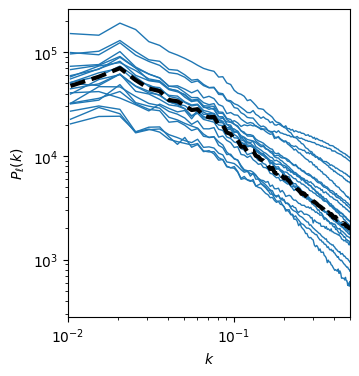

In [16]:
fig = plt.figure(figsize=(8,4))
sub = fig.add_subplot(121)

for _p0k in p0ks: 
    sub.plot(k, _p0k, c='C0', lw=1)    
    
sub.plot(r_hod.poles['k'], (r_hod.poles['power_0'].real - r_hod.poles.attrs['shotnoise']), c='k', ls='--', lw=3)

sub.set_xlabel('$k$')
sub.set_xlim(1e-2, 0.5)
sub.set_xscale('log')
sub.set_ylabel('$P_\ell(k)$')
sub.set_yscale('log')
#sub.set_ylim(-1e3, 4e3)

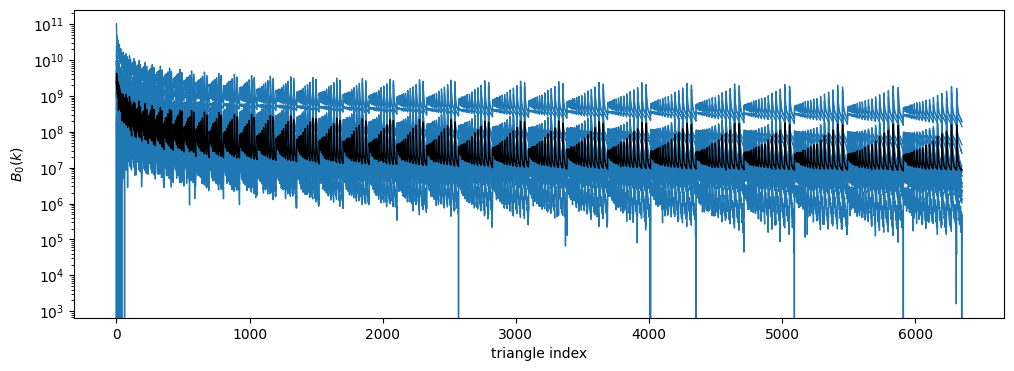

In [67]:
fig = plt.figure(figsize=(12,4))
sub = fig.add_subplot(111)

    

for _b0 in b123s:
    sub.plot(range(_b0.shape[0]), _b0, c='C0', ls='-', lw=1)

sub.plot(range(_b123_hod.shape[0]), _b123_hod, c='k', ls='-', lw=1, label='HOD')
sub.set_xlabel('triangle index')

# sub.set_xscale('log')
sub.set_ylabel('$B_0(k)$')
sub.set_yscale('log')

In [68]:
q123s.shape

(20, 6350)

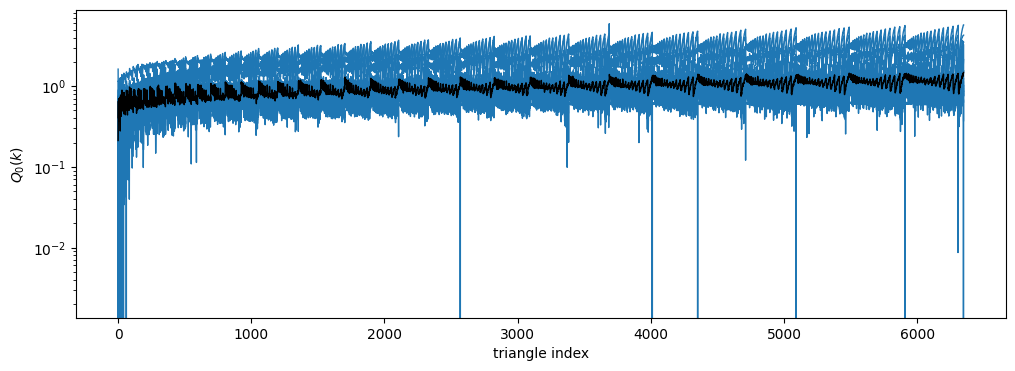

In [69]:
fig = plt.figure(figsize=(12,4))
sub = fig.add_subplot(111)
_q123_hod = bispec_hod['q123'][klim]
    

for _q0 in q123s:
    sub.plot(range(_q0.shape[0]), _q0, c='C0', ls='-', lw=1)

sub.plot(range(_q123_hod.shape[0]), _q123_hod, c='k', ls='-', lw=1, label='HOD')
sub.set_xlabel('triangle index')

# sub.set_xscale('log')
sub.set_ylabel('$Q_0(k)$')
sub.set_yscale('log')

In [ ]:
fig = plt.figure(figsize=(12,4))
sub = fig.add_subplot(111)

    

for _q0 in q123s:
    sub.plot(range(_b0.shape[0]), _b0, c='C0', ls='-', lw=1)

sub.plot(range(_b123_hod.shape[0]), _b123_hod, c='k', ls='-', lw=1, label='HOD')
sub.set_xlabel('triangle index')

# sub.set_xscale('log')
sub.set_ylabel('$B_0(k)$')
sub.set_yscale('log')

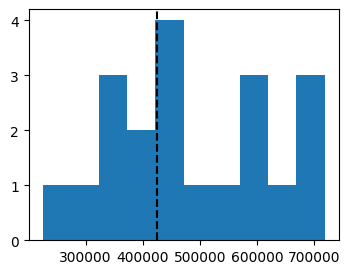

In [17]:
fig = plt.figure(figsize=(4,3))
sub = fig.add_subplot(111)
_ = sub.hist(ngs)
sub.axvline(ng_hod, color='k', linestyle='--')

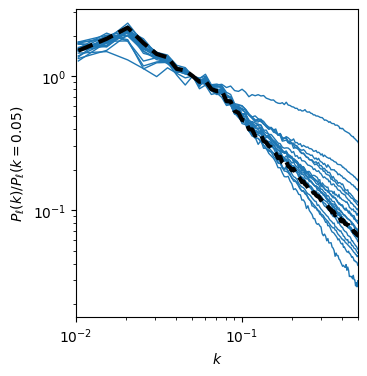

In [18]:
fig = plt.figure(figsize=(8,4))
sub = fig.add_subplot(121)

p0k_fix = (r_hod.poles['power_0'].real - r_hod.poles.attrs['shotnoise'])[np.argmin(np.abs(r_hod.poles['k'] - 0.05))]

for _p0k in p0ks: 
    sub.plot(k, _p0k/_p0k[np.argmin(np.abs(k - 0.05))], c='C0', lw=1)    
    
sub.plot(r_hod.poles['k'], (r_hod.poles['power_0'].real - r_hod.poles.attrs['shotnoise'])/p0k_fix, c='k', ls='--', lw=3)

sub.set_xlabel('$k$')
sub.set_xlim(1e-2, 0.5)
sub.set_xscale('log')
sub.set_ylabel('$P_\ell(k)/P_\ell(k=0.05)$')
sub.set_yscale('log')
#sub.set_ylim(-1e3, 4e3)

# now the more restrictive bias model

In [13]:
_, p0ks0, ngs0 = sample_pk(bias_model='nonlocal0', Nsample=20)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


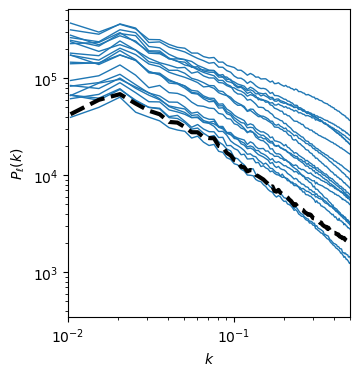

In [14]:
fig = plt.figure(figsize=(8,4))
sub = fig.add_subplot(121)

for _p0k in p0ks0: 
    sub.plot(k, _p0k, c='C0', lw=1)    
    
sub.plot(r_hod.poles['k'], (r_hod.poles['power_0'].real - r_hod.poles.attrs['shotnoise']), c='k', ls='--', lw=3)

sub.set_xlabel('$k$')
sub.set_xlim(1e-2, 0.5)
sub.set_xscale('log')
sub.set_ylabel('$P_\ell(k)$')
sub.set_yscale('log')
#sub.set_ylim(-1e3, 4e3)

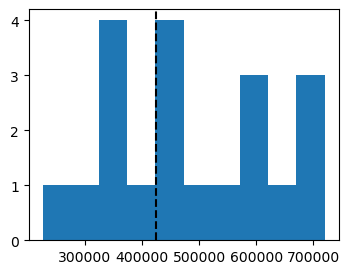

In [18]:
fig = plt.figure(figsize=(4,3))
sub = fig.add_subplot(111)
_ = sub.hist(ngs0)
sub.axvline(ng_hod, color='k', linestyle='--')

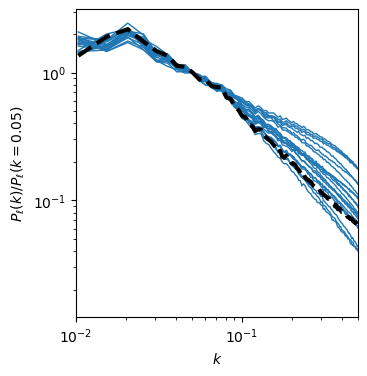

In [15]:
fig = plt.figure(figsize=(8,4))
sub = fig.add_subplot(121)

p0k_fix = (r_hod.poles['power_0'].real - r_hod.poles.attrs['shotnoise'])[np.argmin(np.abs(r_hod.poles['k'] - 0.05))]

for _p0k in p0ks0: 
    sub.plot(k, _p0k/_p0k[np.argmin(np.abs(k - 0.05))], c='C0', lw=1)    
    
sub.plot(r_hod.poles['k'], (r_hod.poles['power_0'].real - r_hod.poles.attrs['shotnoise'])/p0k_fix, c='k', ls='--', lw=3)

sub.set_xlabel('$k$')
sub.set_xlim(1e-2, 0.5)
sub.set_xscale('log')
sub.set_ylabel('$P_\ell(k)/P_\ell(k=0.05)$')
sub.set_yscale('log')
#sub.set_ylim(-1e3, 4e3)

## conclusion
Yes. Let's keep `rhoeps` and `eps`.